# TabPFN Hands-On-Demo

**Welcome to this enhanced and educational walkthrough of TabPFN!**

TabPFN is a novel machine learning model that is exceptionally fast and requires no hyperparameter tuning. It is particularly powerful for tabular data, which is a common data format in many real-world applications. This notebook will not only demonstrate how to use TabPFN but also provide clear explanations of the underlying concepts.

**What you will learn:**

* What TabPFN is and why it's a game-changer for tabular data.
* How to set up and run TabPFN on your local machine or using the client API.
* How to use TabPFN for both classification and regression tasks.
* A comparison of TabPFN's performance against other popular models like XGBoost and RandomForest.
* Advanced features of TabPFN, including handling text data, unsupervised learning, and model interpretability.

Let's get started!



## Table of Contents

1.  [Installation](#installation)
2.  [Backend Selection](#backend-selection)
3.  [**Classification with TabPFN**](#classification)
4.  [**Regression with TabPFN**](#regression)
5.  ~~[Handling Text Data](#text-data)~~
6.  ~~[Unsupervised Learning with TabPFN](#unsupervised-learning)~~
   - ~~Data Imputation~~
   - ~~Anomaly Detection~~
   - ~~Clustering Applications~~
7.  [Model Interpretability](#interpretability)
   - Feature Importance Analysis
   - Explaining Predictions with SHAP
   - Extracting and Visualizing Embeddings
8.  ~~[Predictive Behavior](#behavior)~~
9.  ~~[**Time Series Prediction with TabPFN**](#timeseries)~~
9.  ~~[Using TabPFN to estimate the effect of causal interventions](#causal)~~


# Installation [Running this cell required!] <a name="installation"></a>

First, we need to install the necessary libraries. This includes TabPFN itself, as well as other libraries for data manipulation and baseline model comparisons. If you are asked to restart the runtime after installation, please do so.


In [1]:
## Base library Installation
# Install Baselines for model comparison
!uv pip install catboost xgboost

# Install the datasets library for loading example data
!uv pip install datasets

# Install rich for better and more readable printing
!uv pip install rich

## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!uv pip install tabpfn-client

# Install TabPFN extensions for additional functionalities
!uv pip install 'tabpfn-extensions[all]'

# Install tabpfn
!uv pip install tabpfn

Using Python 3.12.13 environment at: /usr
Resolved 21 packages in 423ms
Prepared 1 package in 2.16s
Installed 1 package in 7ms
 + catboost==1.2.10
Using Python 3.12.13 environment at: /usr
Checked 1 package in 290ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 176ms
Using Python 3.12.13 environment at: /usr
Resolved 33 packages in 903ms
Prepared 5 packages in 178ms
Uninstalled 1 package in 5ms
Installed 5 packages in 34ms
 + backoff==2.2.1
 + password-strength==0.0.3.post2
 + sseclient-py==1.8.0
 + tabpfn-client==0.2.8
 - tqdm==4.67.3
 + tqdm==4.67.1
Using Python 3.12.13 environment at: /usr
Resolved 110 packages in 2.21s
Prepared 20 packages in 1.93s
Uninstalled 1 package in 2ms
Installed 20 packages in 207ms
 + autogluon-common==1.4.0
 + autogluon-core==1.4.0
 + autogluon-features==1.4.0
 + autogluon-tabular==1.4.0
 + boto3==1.42.93
 + botocore==1.42.93
 + colour==0.1.5
 + ecos==2.0.14
 + eval-type-backport==0.3.1
 + galois==0.4.10
 + jmespath==1.1.0
 + posthog==7.1

***Note: remember to restart the runtime after the installation.***

# Necessary Imports for the Notebook [Running this cell required!]

Now that the libraries are installed, let's import all the necessary modules for this notebook.




In [1]:
# Standard Library Imports

# TabPFN and Extensions

try:
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )

    from tabpfn import TabPFNClassifier, TabPFNRegressor
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Other ML Models
from catboost import CatBoostClassifier, CatBoostRegressor

# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.rule import Rule
from sklearn.compose import make_column_selector, make_column_transformer

# Scikit-Learn: Data & Preprocessing
from sklearn.datasets import fetch_openml, load_breast_cancer

# Scikit-Learn: Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier, XGBRegressor

# This transformer will be used to handle categorical features for the baseline models
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)

# Backend Selection [Running this cell required!] <a name="backend-selection"></a>


TabPFN can be run in two ways: locally on your machine (if you have a GPU) or by using the TabPFN client, which sends the data to a server for computation.
In your project you would either use the **local** version (which requires a GPU) with:
```python
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

or the **client** API (which uses a remote server):

```python
# Simple import for TabPFN
from tabpfn_client import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

If you select **local** and it's your first time using the model, you'll need to accept the license agreement and log into Hugging Face.
You'll be prompted with instructions on how to do this the first time you fit the model.

For demonstration purposes, the cell below provides an interactive way to switch between local mode and the client:


In [2]:
# Authentication code - No need to read it!

console = Console()

console.print(Panel.fit("[bold magenta]TabPFN Demo: Backend Selection[/bold magenta]"))
console.print("\nThis script can run TabPFN using one of two backends:")
console.print("  [bold]local:[/bold] Uses a local GPU (NVIDIA). Requires CUDA.")
console.print(
    "  [bold]client:[/bold] Uses the TabPFN API. Requires an internet connection and a free account."
)

backend = None
while backend is None:
  console.print(
      "\n[bold]Choose your backend[/bold]: - If no text box is shown, restart the cell.",
  )
  user_input = input("Enter 'local' or 'client' and press return:")
  if user_input not in ["local", "client"]:
    continue
  backend = user_input

console.print(
    f"\n✅ You have selected the '[bold green]{backend}[/bold green]' backend."
)

console.print(Rule(f"[bold]Setting up [cyan]{backend}[/cyan] backend[/bold]"))

if backend == "local":
    console.print("Attempting local backend setup...")
    import torch

    if not torch.cuda.is_available():
        console.print(
            "[bold red]Error:[/bold red] GPU device not found. For fast training, please enable GPU.",
            style="red",
        )
        console.print(
            "In Colab: Go to [bold]Runtime -> Change runtime type -> Hardware accelerator -> GPU.[/bold]",
            style="yellow",
        )
        raise SystemError("GPU device not found.")
    console.print("[bold green]✅ GPU is available.[/bold green]")

    # --- Prior Labs Authentication ---
    console.print(Rule("[bold]Prior Labs Authentication[/bold]"))
    console.print(
        "\nTabPFN model weights require a free [bold]Prior Labs account[/bold] and "
        "acceptance of the non-commercial license.\n"
    )

    import os
    import getpass

    tabpfn_token = None

    # 1. Try Colab secret TABPFN_TOKEN
    try:
        from google.colab import userdata
        tabpfn_token = userdata.get("TABPFN_TOKEN")
        if tabpfn_token:
            os.environ["TABPFN_TOKEN"] = tabpfn_token
            console.print("[bold green]✅ Found TABPFN_TOKEN in Colab secrets.[/bold green]")
    except Exception:
        pass

    # 2. If no token found, prompt the user
    if not tabpfn_token:
        console.print(
            Panel(
                "To get your access token:\n\n"
                "  1. Go to [link=https://ux.priorlabs.ai]ux.priorlabs.ai[/link] and sign up / log in\n"
                "  2. Accept the license at [link=https://ux.priorlabs.ai/account/licenses]ux.priorlabs.ai/account/licenses[/link]\n"
                "  3. Copy your Access Token from [link=https://ux.priorlabs.ai/account]ux.priorlabs.ai/account[/link]\n\n"
                "[bold yellow]Tip:[/bold yellow] Save the token as a Colab secret named "
                "[bold cyan]TABPFN_TOKEN[/bold cyan] to skip this step next time.",
                title="[bold]🔑 Prior Labs Access Token required",
                border_style="blue",
            )
        )
        while not tabpfn_token:
            token_input = getpass.getpass("Paste your TABPFN_TOKEN and press Enter: ")
            if token_input.strip():
                tabpfn_token = token_input.strip()
                os.environ["TABPFN_TOKEN"] = tabpfn_token
            else:
                console.print("[red]Token cannot be empty. Please try again.[/red]")

    console.print("")
    console.print("Importing local TabPFN library...")

    from tabpfn import TabPFNClassifier, TabPFNRegressor

    console.print("[bold green]✅ TabPFN (local) imported successfully.[/bold green]")
elif backend == "client":
    console.print("Attempting client backend setup...")
    console.print("Importing TabPFN client library...")
    from tabpfn_client import TabPFNClassifier, TabPFNRegressor, init

    init()
    console.print("[bold green]✅ TabPFN (client) initialized.[/bold green]")


╭────────────────────────────────╮
│ TabPFN Demo: Backend Selection │
╰────────────────────────────────╯

This script can run TabPFN using one of two backends:

local: Uses a local GPU (NVIDIA). Requires CUDA.

client: Uses the TabPFN API. Requires an internet connection and a free account.

Choose your backend: - If no text box is shown, restart the cell.

...

TabPFN model weights require a free Prior Labs account and acceptance of the non-commercial license.

╭────────────────────────────────────── 🔑 Prior Labs Access Token required ──────────────────────────────────────╮
│ To get your access token:                                                                                       │
│                                                                                                                 │
│   1. Go to ]8;id=582016;https://ux.priorlabs.ai\ux.priorlabs.ai]8;;\ and sign up / log in                                                                 │
│   2. Accept the license at ]8;id=25215;https://ux.priorlabs.ai/account/licenses\ux.priorlabs.ai/account/licenses]8;;\                                                     │
│   3. Copy your Access Token from ]8;id=795756;https://ux.priorlabs.ai/account\ux.priorlabs.ai/account]8;;\                                                        │
│                                                                                                                 │
│ Tip: Save the token as a Colab secret named TABPFN_TOKEN to skip this step next time.                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Paste your TABPFN_TOKEN and press Enter: ··········


Importing local TabPFN library...

✅ TabPFN (local) imported successfully.

# Classification with TabPFN <a name="classification"></a>

Now, let's dive into a practical example of using TabPFN for a classification task. We will use the well-known Parkinson's Disease dataset. The goal is to predict the presence of Parkinson's disease based on various voice measurements.

We will compare TabPFN's performance against other popular machine learning models: RandomForest, XGBoost, and CatBoost. The performance metric we will use is the [ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) score.


### **Loading Parkinson’s Disease Dataset**

**Source:**  
The dataset was created by _Max Little_ of the **University of Oxford**, in collaboration with the **National Centre for Voice and Speech**, Denver, Colorado. The dataset consists of biomedical voice measurements collected from individuals, and the original study published the feature extraction methods for general voice disorders.

### **Dataset Overview**

-   **Number of subjects:** 31
    
-   **Number of Parkinson’s disease (PD) patients:** 23
    
-   **Total recordings:** 195 voice samples
    
-   **Goal:** To discriminate healthy individuals (status = 0) from those with Parkinson’s disease (status = 1).
    
-   **Identifier column:** `name` (subject name and recording number)
    

<details>
If you use this dataset, please cite:

> Max A. Little, Patrick E. McSharry, Eric J. Hunter, Lorraine O. Ramig (2008).  
> _Suitability of dysphonia measurements for telemonitoring of Parkinson's disease._  
> IEEE Transactions on Biomedical Engineering.

* * *



* * *

### **Attribute Information**

Each row corresponds to a voice recording, and each column represents a distinct biomedical voice measure.

**Feature Name**

**Description**

`name`

ASCII subject name and recording number

`MDVP:Fo(Hz)`

Average vocal fundamental frequency

`MDVP:Fhi(Hz)`

Maximum vocal fundamental frequency

`MDVP:Flo(Hz)`

Minimum vocal fundamental frequency

`MDVP:Jitter(%)`, `MDVP:Jitter(Abs)`, `MDVP:RAP`, `MDVP:PPQ`, `Jitter:DDP`

Measures of variation in fundamental frequency

`MDVP:Shimmer`, `MDVP:Shimmer(dB)`, `Shimmer:APQ3`, `Shimmer:APQ5`, `MDVP:APQ`, `Shimmer:DDA`

Measures of variation in amplitude

`NHR`, `HNR`

Ratios of noise to tonal components in the voice

`status`

Health status of the subject (`0` = healthy, `1` = Parkinson’s disease)

`RPDE`, `D2`

Nonlinear dynamical complexity measures

`DFA`

Signal fractal scaling exponent

`spread1`, `spread2`, `PPE`

Nonlinear measures of fundamental frequency variation
</details>


In [3]:
# Load Parkinsons dataset described above

import pandas as pd, io, zipfile, requests

url_zip = "https://archive.ics.uci.edu/static/public/174/parkinsons.zip"
with requests.get(url_zip) as r:
    r.raise_for_status()
    zf = zipfile.ZipFile(io.BytesIO(r.content))
    df = pd.read_csv(zf.open("parkinsons.data"))
X, y = df.drop(["status", "name"], axis=1), df["status"]

display(X)

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,...,0.02745,0.07008,0.02764,19.517,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,...,0.01879,0.04812,0.01810,19.147,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,...,0.01667,0.03804,0.10715,17.883,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,...,0.01588,0.03794,0.07223,19.020,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [ ]:
# Alternative datasets (commented for reference):

# Cholesterol dataset: Predict cholesterol levels
# Features: Patient characteristics, medical measurements
# Samples: 303 patients
# Target: Cholesterol levels in mg/dl
# df = fetch_openml('cholesterol', version=2, as_frame=True)

# Heart Disease dataset (Statlog): Predict presence of heart disease
# Features: Clinical and test measurements
# Samples: 270 patients
# Target: Binary heart disease diagnosis
# df = fetch_openml("heart-statlog", version=1)

# Diabetes dataset: Predict diabetes presence
# Features: Medical measurements, patient history
# Samples: 768 patients
# Target: Binary diabetes diagnosis
# df = fetch_openml("diabetes", version=1)

In [4]:
from xgboost import XGBClassifier

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train and evaluate the TabPFN classifier
tabpfn_classifier = TabPFNClassifier(random_state=42)
tabpfn_classifier.fit(X_train, y_train)
y_pred_proba_tabpfn = tabpfn_classifier.predict_proba(X_test)

roc_auc_tabpfn = roc_auc_score(y_test, y_pred_proba_tabpfn[:, 1])
print(f"TabPFN ROC AUC Score: {roc_auc_tabpfn:.4f}")

# Train and evaluate XGBoost
xgb_classifier = XGBClassifier(random_state=42)
xgb_classifier.fit(X_train, y_train)
y_pred_proba_xgb = xgb_classifier.predict_proba(X_test)

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb[:, 1])
print(f"XGBoost ROC AUC Score: {roc_auc_xgb:.4f}")

tabpfn-v2.5-classifier-v2.5_default.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

TabPFN ROC AUC Score: 0.9732
XGBoost ROC AUC Score: 0.9196


### Comparing TabPFN with Other Classifiers

To get a better sense of TabPFN's performance, let's compare it with other popular classification models using cross-validation. This will give us a more robust estimate of each model's performance.


[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:   37.0s finished
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:    4.6s finished
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:  1.5min finished


,Model,ROC AUC,ROC AUC CI95,Balanced Accuracy,Log Loss,PR AUC
0,TabPFN,0.9843,0.0080,0.9222,0.1459,0.9945
3,CatBoost,0.9772,0.0092,0.8742,0.1824,0.9925
2,XGBoost,0.9656,0.0135,0.8651,0.2226,0.9882
1,RandomForest,0.9596,0.0134,0.8356,0.2373,0.9859


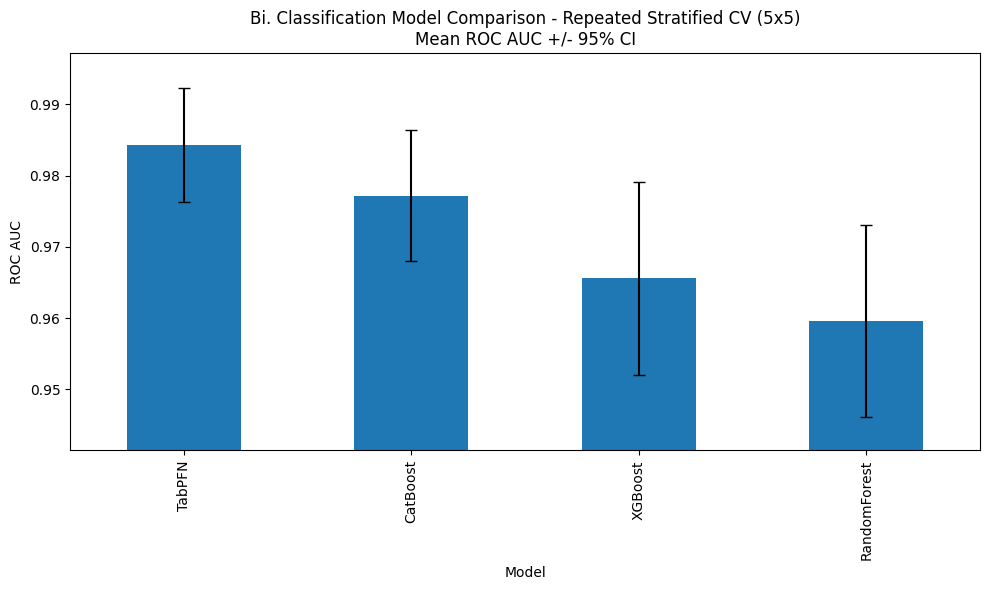

In [6]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from scipy.stats import t as student_t

# Encode target labels to classes for baselines
le = LabelEncoder()
y = le.fit_transform(y)

# Define models
models = [
    ("TabPFN", TabPFNClassifier(random_state=42)),
    (
        "RandomForest",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            RandomForestClassifier(random_state=42),
        ),
    ),
    (
        "XGBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            XGBClassifier(random_state=42),
        ),
    ),
    (
        "CatBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            CatBoostClassifier(random_state=42, verbose=0),
        ),
    ),
]

# Use repeated stratified CV for more stable estimates
n_splits = 5
n_repeats = 5
cv = RepeatedStratifiedKFold(
    n_splits=n_splits,
    n_repeats=n_repeats,
    random_state=42,
)

# Use multiple metrics for a more complete comparison
n_classes = len(np.unique(y))
if n_classes > 2:
    scoring = {
        "roc_auc": "roc_auc_ovr_weighted",
        "balanced_accuracy": "balanced_accuracy",
        "neg_log_loss": "neg_log_loss",
    }
else:
    scoring = {
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "balanced_accuracy": "balanced_accuracy",
        "neg_log_loss": "neg_log_loss",
    }

results = {}
for name, model in models:
    results[name] = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        verbose=1,
        error_score="raise",
    )

# Build summary table with mean metrics and 95% CI for ROC AUC
rows = []
for name, res in results.items():
    roc_scores = np.asarray(res["test_roc_auc"])
    n = len(roc_scores)
    roc_mean = roc_scores.mean()
    roc_std = roc_scores.std(ddof=1)
    t_crit = student_t.ppf(0.975, df=n - 1)
    roc_ci95 = t_crit * roc_std / np.sqrt(n)

    row = {
        "Model": name,
        "ROC AUC": roc_mean,
        "ROC AUC CI95": roc_ci95,
        "Balanced Accuracy": np.mean(res["test_balanced_accuracy"]),
        "Log Loss": -np.mean(res["test_neg_log_loss"]),
    }

    if "test_pr_auc" in res:
        row["PR AUC"] = np.mean(res["test_pr_auc"])

    rows.append(row)

summary = pd.DataFrame(rows).sort_values("ROC AUC", ascending=False)
display(summary.round(4))

# Plot ROC AUC with 95% CI error bars
ax = summary.plot(
    x="Model",
    y="ROC AUC",
    yerr="ROC AUC CI95",
    kind="bar",
    capsize=4,
    figsize=(10, 6),
    legend=False,
)

lower = max(0.0, (summary["ROC AUC"] - summary["ROC AUC CI95"]).min() * 0.995)
upper = min(1.0, (summary["ROC AUC"] + summary["ROC AUC CI95"]).max() * 1.005)
ax.set_ylim(lower, upper)
ax.set_ylabel("ROC AUC")
ax.set_title(
    f"Bi. Classification Model Comparison - Repeated Stratified CV ({n_splits}x{n_repeats})\nMean ROC AUC +/- 95% CI"
)
plt.tight_layout()



# Regression with TabPFN <a name="regression"></a>

Next, we'll explore how to use TabPFN for regression tasks. We will use the Boston Housing dataset, where the goal is to predict the median value of owner-occupied homes.

We will measure performance using the [Root Mean Squared Error](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.root_mean_squared_error.html), and again, we will compare TabPFN with other popular regression models.

### **Loading Boston Housing Dataset**

### **Dataset Overview**

-   **Objective:** Predict the **median value of owner-occupied homes** in the Boston area based on various socioeconomic and environmental attributes.
    
-   **Number of Instances:** 506
    
-   **Number of Attributes:** 14 (13 numeric features + 1 target variable)
    
-   **Target Variable:** `MEDV` — Median value of owner-occupied homes (in $1000s)
    
-   **Class Type:** Numeric
    
-   **Class Index:** Last
    

* * *

<details>


**Citation:**

> Harrison, D. and Rubinfeld, D.L. (1978).  
> _Hedonic prices and the demand for clean air._  
> _Journal of Environmental Economics & Management_, 5, 81–102.  
> Used in Belsley, Kuh & Welsch, _Regression Diagnostics: Identifying Influential Data and Sources of Collinearity_, Wiley, 1980.


### **Attribute Information**

**Feature**

**Description**

`CRIM`

Per capita crime rate by town

`ZN`

Proportion of residential land zoned for lots over 25,000 sq.ft.

`INDUS`

Proportion of non-retail business acres per town

`CHAS`

Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

`NOX`

Nitric oxides concentration (parts per 10 million)

`RM`

Average number of rooms per dwelling

`AGE`

Proportion of owner-occupied units built prior to 1940

`DIS`

Weighted distances to five Boston employment centres

`RAD`

Index of accessibility to radial highways

`TAX`

Full-value property-tax rate per $10,000

`PTRATIO`

Pupil–teacher ratio by town

`B`

1000(Bk − 0.63)², where Bk is the proportion of Blacks by town

`LSTAT`

Percentage of lower status population

`MEDV`

Median value of owner-occupied homes (in $1000s)

</details>

In [8]:
# Load the Boston Housing dataset

import pandas as pd, requests
from IPython.display import display, Markdown

cols = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"]
df_boston = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data",
                        delim_whitespace=True, header=None, names=cols)
X, y = df_boston.drop(columns=["MEDV"]), df_boston["MEDV"]

display(X.head())


/tmp/ipykernel_1917/378995386.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_boston = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data",


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [ ]:
# Alternative datasets (commented for reference):

# Liver Disorders dataset
# Classification task: Predict liver disorder presence
# Features: Blood test results, alcohol consumption
# Samples: 345 patients
# Target: Binary liver disorder diagnosis
# df = fetch_openml("liver-disorders", version=1)

# Grid Stability dataset
# Regression task: Predict electrical grid stability
# Features: Power system measurements, grid parameters
# Samples: 10,000 simulations
# Target: Grid stability score
# df = fetch_openml(data_id=44973, as_frame=True)

# Concrete Compressive Strength dataset
# Regression task: Predict concrete strength
# Features: Concrete components (cement, water, aggregates)
# Samples: 1,030 concrete samples
# Target: Compressive strength in MPa
# df = fetch_openml(data_id=44959, as_frame=True)

In [9]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# Train and evaluate the TabPFN regressor
tabpfn_regressor = TabPFNRegressor(random_state=42)
tabpfn_regressor.fit(X_train, y_train)
y_pred = tabpfn_regressor.predict(X_test)

# Calculate the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"TabPFN RMSE: {rmse:.4f}")

tabpfn-v2.5-regressor-v2.5_default.ckpt:   0%|          | 0.00/40.8M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

TabPFN RMSE: 2.6321


### Comparing TabPFN with Other Regressors

Now, let's see how TabPFN's regression performance stacks up against other models using cross-validation.


[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:   18.0s finished
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:   11.3s finished
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:    4.6s finished
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:   51.7s finished


,Model,RMSE,RMSE CI95,MAE,MedAE,R2,R2 CI95
0,TabPFN,2.6804,0.2312,1.7467,1.2275,0.9088,0.0163
3,CatBoost,2.9868,0.1440,2.0358,1.4142,0.8908,0.0088
2,XGBoost,3.2282,0.2022,2.1975,1.5605,0.8704,0.0167
1,RandomForest,3.2615,0.1965,2.2228,1.5686,0.8675,0.0167


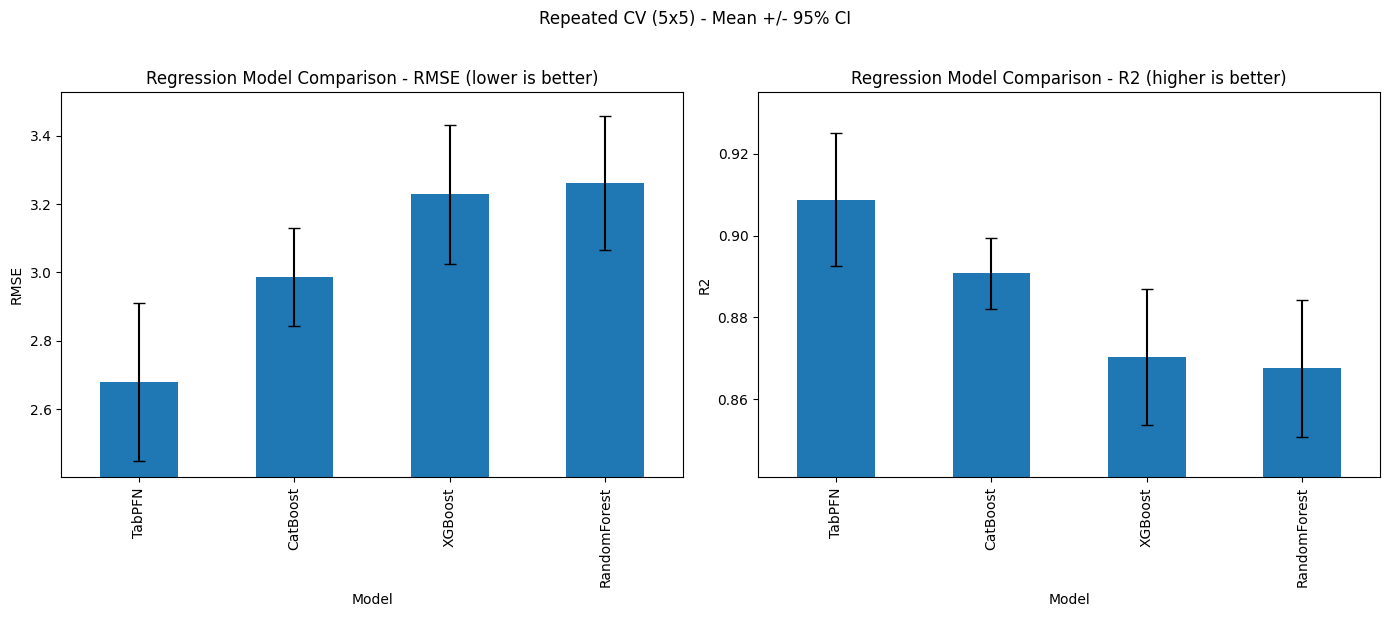

In [11]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate

from sklearn.model_selection import RepeatedKFold, cross_validate
from scipy.stats import t as student_t

# Define models
models = [
    ("TabPFN", TabPFNRegressor(random_state=42)),
    (
        "RandomForest",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            RandomForestRegressor(random_state=42),
        ),
    ),
    (
        "XGBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            XGBRegressor(random_state=42),
        ),
    ),
    (
        "CatBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            CatBoostRegressor(random_state=42, verbose=0),
        ),
    ),
]

# Use repeated CV for a more stable estimate on this small-to-medium dataset
n_splits = 5
n_repeats = 5
cv = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

# Evaluate both error magnitude and explained variance
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "medae": "neg_median_absolute_error",
    "r2": "r2",
}

results = {}
for name, model in models:
    results[name] = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        verbose=1,
        error_score="raise",
    )

# Summarize with 95% confidence intervals for RMSE and R2
rows = []
for name, res in results.items():
    rmse_scores = -np.asarray(res["test_rmse"])
    mae_scores = -np.asarray(res["test_mae"])
    medae_scores = -np.asarray(res["test_medae"])
    r2_scores = np.asarray(res["test_r2"])

    n = len(rmse_scores)
    t_crit = student_t.ppf(0.975, df=n - 1)

    rmse_mean = rmse_scores.mean()
    rmse_ci95 = t_crit * rmse_scores.std(ddof=1) / np.sqrt(n)

    r2_mean = r2_scores.mean()
    r2_ci95 = t_crit * r2_scores.std(ddof=1) / np.sqrt(n)

    rows.append(
        {
            "Model": name,
            "RMSE": rmse_mean,
            "RMSE CI95": rmse_ci95,
            "MAE": mae_scores.mean(),
            "MedAE": medae_scores.mean(),
            "R2": r2_mean,
            "R2 CI95": r2_ci95,
        }
    )

summary = pd.DataFrame(rows).sort_values("RMSE", ascending=True)
display(summary.round(4))

# Plot primary metric (RMSE) and secondary metric (R2) with uncertainty
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

summary.plot(
    x="Model",
    y="RMSE",
    yerr="RMSE CI95",
    kind="bar",
    capsize=4,
    ax=axs[0],
    legend=False,
)
rmse_lower = max(0.0, (summary["RMSE"] - summary["RMSE CI95"]).min() * 0.98)
rmse_upper = (summary["RMSE"] + summary["RMSE CI95"]).max() * 1.02
axs[0].set_ylim(rmse_lower, rmse_upper)
axs[0].set_title("Regression Model Comparison - RMSE (lower is better)")
axs[0].set_ylabel("RMSE")

summary.plot(
    x="Model",
    y="R2",
    yerr="R2 CI95",
    kind="bar",
    capsize=4,
    ax=axs[1],
    legend=False,
)
r2_lower = (summary["R2"] - summary["R2 CI95"]).min()
r2_upper = (summary["R2"] + summary["R2 CI95"]).max()
r2_pad = max(0.01, 0.05 * (r2_upper - r2_lower))
axs[1].set_ylim(r2_lower - r2_pad, min(1.0, r2_upper + r2_pad))
axs[1].set_title("Regression Model Comparison - R2 (higher is better)")
axs[1].set_ylabel("R2")

fig.suptitle(
    f"Repeated CV ({n_splits}x{n_repeats}) - Mean +/- 95% CI",
    y=1.02,
)
plt.tight_layout()



# Model Interpretability <a name="interpretability"></a>

Understanding *why* a model makes certain predictions is crucial for building trust and for debugging. The `tabpfn-extensions` library provides tools for model interpretability. We'll look at SHAP (SHapley Additive exPlanations) values, which show the impact of each feature on a specific prediction.

### Shapley Values

Next, we'll use SHAP to understand our model's predictions. SHAP values break down a prediction to show the contribution of each feature, helping us see which factors are most influential for a given data point.


PermutationExplainer explainer: 26it [02:10,  5.43s/it]


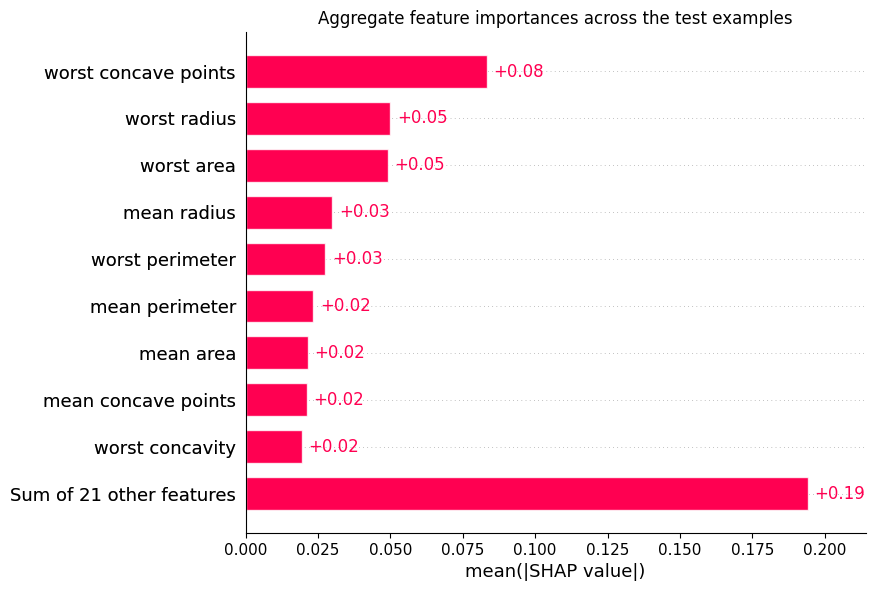

/usr/local/lib/python3.12/dist-packages/tabpfn_extensions/interpretability/shap.py:137: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values=shap_values, show=False)


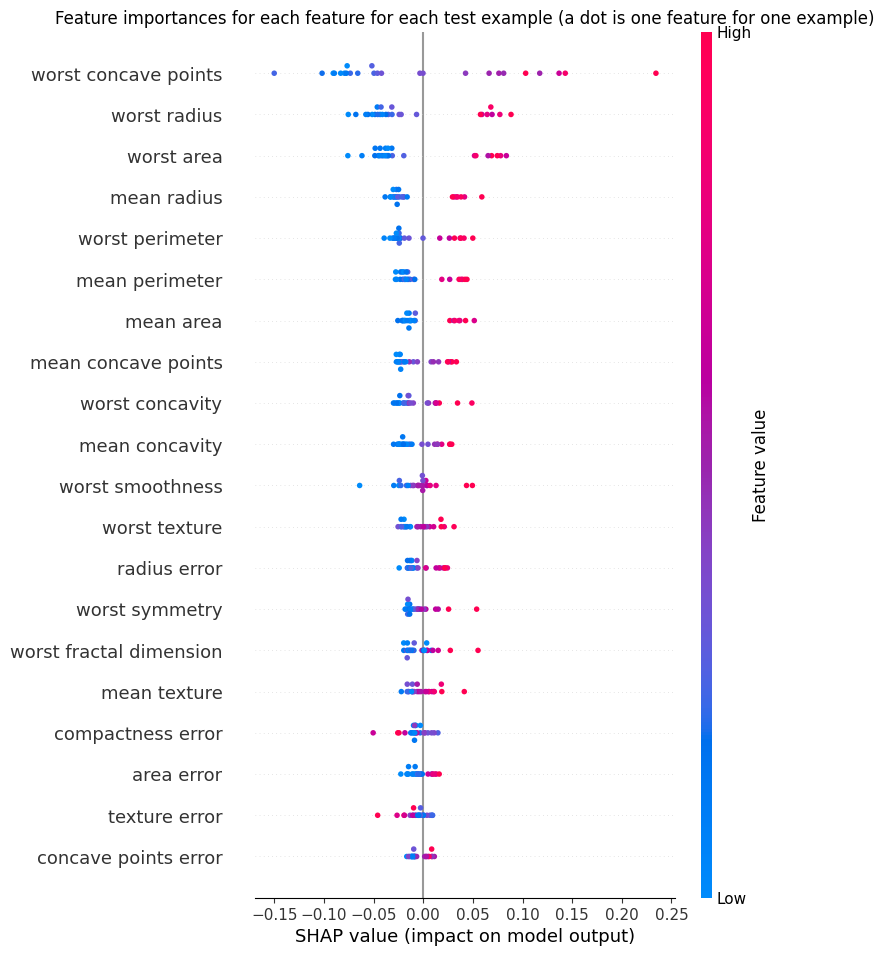

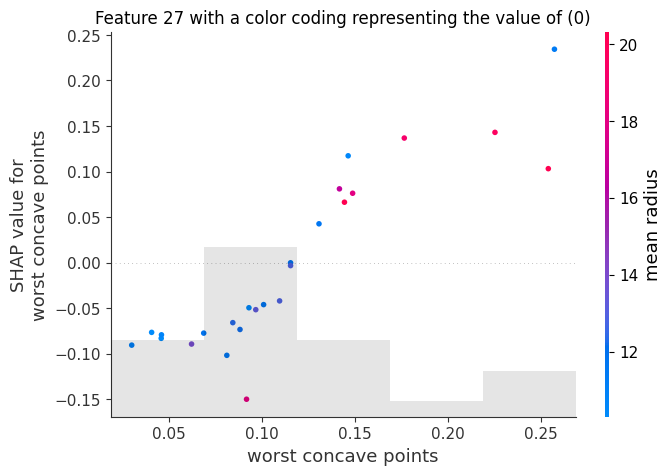

In [9]:
from tabpfn_extensions import interpretability

# Load example dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
n_samples_test, n_samples_train = 25, 50

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

# Initialize and train model
clf = TabPFNClassifier()
clf.fit(X_train[:n_samples_train], y_train[:n_samples_train])

# Calculate SHAP values
shap_values = interpretability.shap.get_shap_values(
    estimator=clf,
    test_x=X_test[:n_samples_test],
    attribute_names=feature_names,
    algorithm="permutation",
)

# Create visualization
fig = interpretability.shap.plot_shap(shap_values)